# TITLE

Here, we're going to be analyzing and unpacking data from businesses in Middletown, CT. Among businesses currently active in Middletown, when were they registered (specifically diving into new and upcoming businesses in the past 5 years)?

### Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime



### Load the data

In [4]:
df = pd.read_csv("../data/MiddletownBusinesses.csv")

df["Date_Registration"] = pd.to_datetime(df["Date_Registration"], errors="coerce")

In [16]:
df["reg_year"] = df["Date_Registration"].dt.year

In [17]:
current_year = datetime.today().year
start_year = current_year - 4

recent_businesses = df[df["reg_year"] >= start_year]

year_counts = recent_businesses["reg_year"].value_counts().sort_index()

print(year_counts)

reg_year
2022    272
2023    306
2024    426
2025    585
2026    167
Name: count, dtype: int64


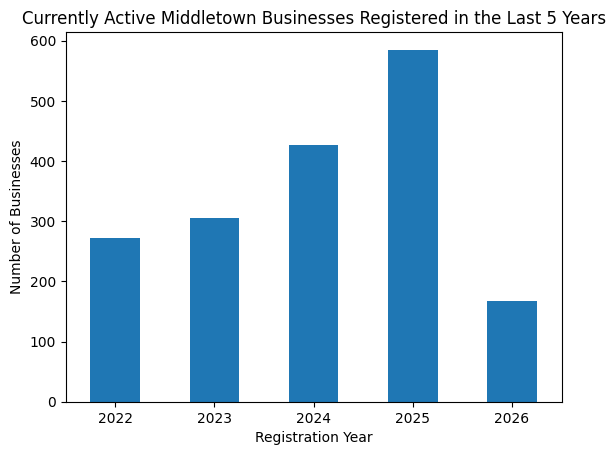

In [18]:
year_counts.plot(kind="bar")
plt.title("Currently Active Middletown Businesses Registered in the Last 5 Years")
plt.xlabel("Registration Year")
plt.ylabel("Number of Businesses")
plt.xticks(rotation=0)
plt.show()

Next, we're going to be examining the business age distribution in Middletown, CT

In [19]:
df["business_age"] = current_year - df["reg_year"]

print(df["business_age"].describe())

count    3792.000000
mean       10.543249
std        13.359831
min         0.000000
25%         2.000000
50%         5.000000
75%        14.000000
max       120.000000
Name: business_age, dtype: float64


In [20]:
bins = [0, 1, 3, 5, 10, 25, 50, 100, 200]
labels = ["0-1 years", "2-3 years", "4-5 years", "6-10 years", "11-25 years", "26-50 years", "51-100 years", "100+ years"]

df["age_group"] = pd.cut(df["business_age"], bins=bins, labels=labels, right=True)

age_counts = df["age_group"].value_counts().sort_index()
print(age_counts)

age_group
0-1 years       585
2-3 years       732
4-5 years       492
6-10 years      609
11-25 years     772
26-50 years     350
51-100 years     80
100+ years        5
Name: count, dtype: int64


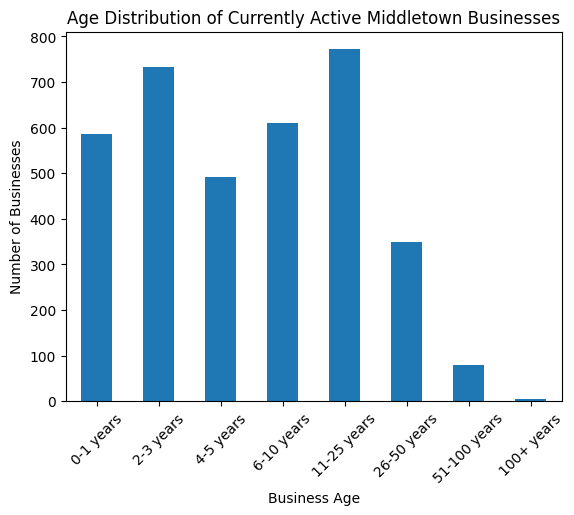

In [21]:
age_counts.plot(kind="bar")
plt.title("Age Distribution of Currently Active Middletown Businesses")
plt.xlabel("Business Age")
plt.ylabel("Number of Businesses")
plt.xticks(rotation=45)
plt.show()

Finally, we're going to be conducting a business type breakdown.

In [22]:
df["Business_Type"].value_counts().head(10)

Business_Type
LLC                    3101
Stock                   343
Non-Stock               306
Limited Partnership      15
Statutory Trust          11
LLP                       9
Religious                 4
B Corp                    3
Name: count, dtype: int64

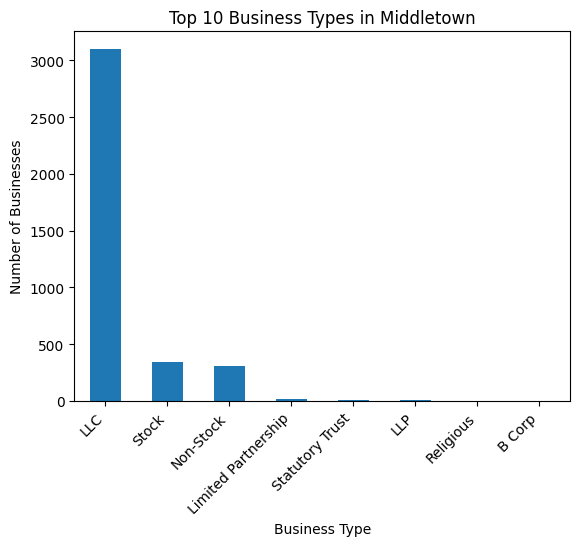

In [23]:
top_types = df["Business_Type"].value_counts().head(10)

top_types.plot(kind="bar")
plt.title("Top 10 Business Types in Middletown")
plt.xlabel("Business Type")
plt.ylabel("Number of Businesses")
plt.xticks(rotation=45, ha="right")
plt.show()

In [24]:
df["NAICS_Code"].value_counts().head(15)

NAICS_Code
Other Activities Related to Real Estate (531390)                                 193
Lessors of Residential Buildings and Dwellings (531110)                          177
Lessors of Nonresidential Buildings (except Miniwarehouses) (531120)             106
Residential Remodelers (236118)                                                   91
Lessors of Other Real Estate Property (531190)                                    82
Residential Property Managers (531311)                                            79
All Other Personal Services (812990)                                              72
Administrative Management and General Management Consulting Services (541611)     66
Full-Service Restaurants (722511)                                                 64
Offices of Mental Health Practitioners (except Physicians) (621330)               55
All Other General Merchandise Retailers (455219)                                  53
Beauty Salons (812112)                                

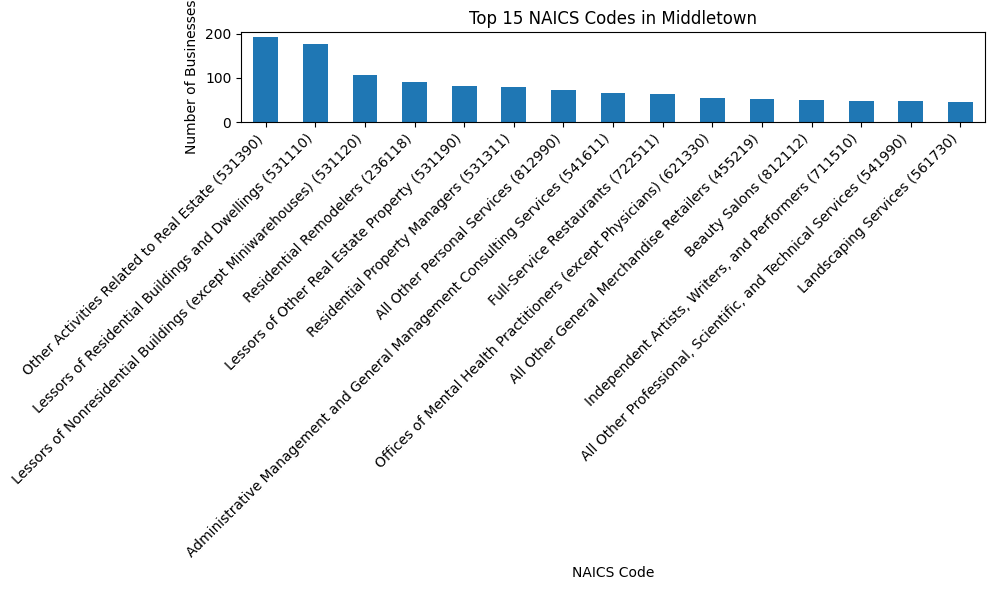

In [25]:
top_naics = df["NAICS_Code"].value_counts().head(15)

plt.figure(figsize=(10,6))
top_naics.plot(kind="bar")

plt.title("Top 15 NAICS Codes in Middletown")
plt.xlabel("NAICS Code")
plt.ylabel("Number of Businesses")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()